In [1]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '1'

import numpy as np
from mlcolvar.io import load_dataframe
from mlcolvar.utils.fes import compute_fes
from mlcolvar.utils.plot import paletteFessa
import matplotlib.pyplot as plt

/leonardo_scratch/fast/IscrB_ProAmmo/envs/compcatschool/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load COLVAR file containing collective variables 
colvar = load_dataframe("700K_explore/COLVAR")
colvar.head()

,time,d_N2,c_N_Fe,w_d_N2.bias,w_d_N2.force2,w_com_N2.bias,w_com_N2.force2,opes.bias,opes.rct,opes.zed,opes.neff,opes.nker,walker
0,0.0,1.240547,6.491348,0.0,0.0,0.0,0.0,-0.6,-0.6,1.0,1.000096,0.0,0
1,0.1,1.272160,6.606203,0.0,0.0,0.0,0.0,-0.6,-0.6,1.0,1.000096,0.0,0
2,0.2,1.301897,6.124446,0.0,0.0,0.0,0.0,-0.6,-0.6,1.0,1.000096,0.0,0
3,0.3,1.310382,6.110750,0.0,0.0,0.0,0.0,-0.6,-0.6,1.0,1.000096,0.0,0
4,0.4,1.253615,5.693764,0.0,0.0,0.0,0.0,-0.6,-0.6,1.0,1.000096,0.0,0


<Axes: xlabel='time'>

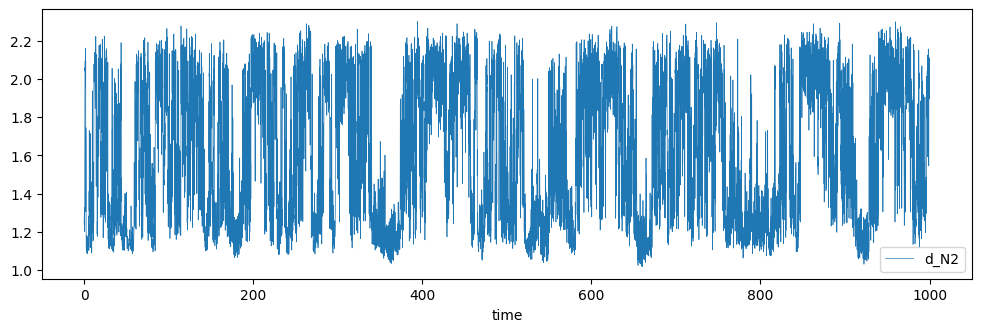

In [9]:
colvar.plot(x="time",y="d_N2", linewidth=0.5, figsize=(12,3.5))

<Axes: xlabel='d_N2', ylabel='c_N_Fe'>

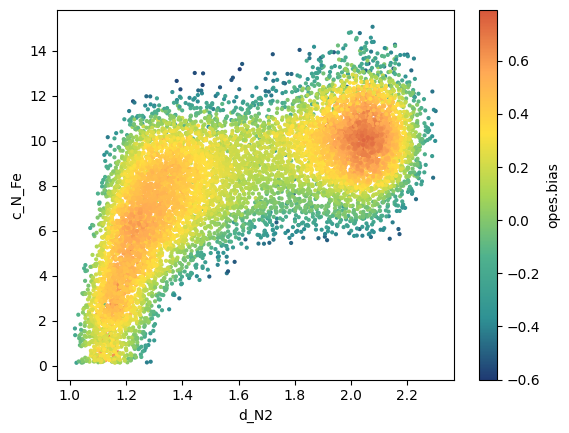

In [10]:
colvar.plot.scatter(x="d_N2",y="c_N_Fe",c="opes.bias",cmap='fessa', s=4)

<Axes: xlabel='time'>

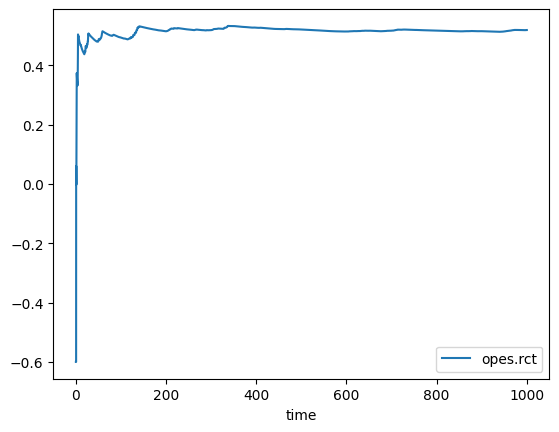

In [11]:
colvar.plot(x="time",y="opes.rct")

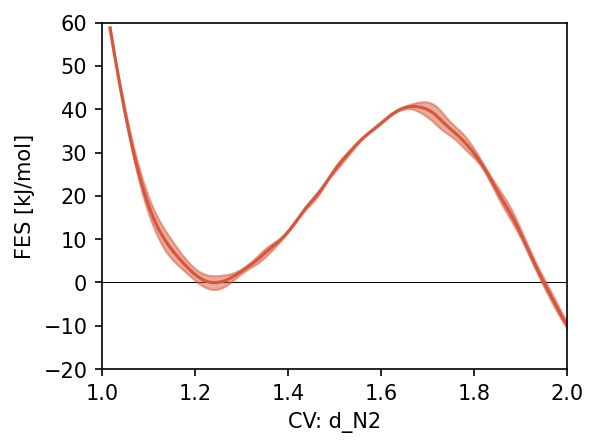

In [7]:
# Discard initial part of the trajectory for equilibration
colvar2 = colvar[colvar.time > 200]
colvar2 = colvar2[colvar2.d_N2 < 2.05]
cv_name = 'd_N2'

cv1 = colvar2[cv_name].values

# kBT 
temperature = 700
kb = 0.0083144621 / 96      # Boltzmann constant ev/K
kbt = kb * temperature

# Calculate weight: reweight all field *.bias in the COLVAR
bias = colvar2.filter(regex='.bias').sum(axis=1).values
bias = bias - np.max(bias)
weights = np.exp( bias / kbt )

fes_params = {
    'blocks': 2,            # Number of blocks for error analysis
    'fes_to_zero' : 42,
    'bandwidth': 0.02,      # Kernel bandwidth (sigma) for density estimation. if 'range', the bandwidth is expressed as ratio of the range of values (e.g. here it is 1% of it)
    'scale_by': 'range',    # Method to scale the bandwidth
    'temp' : temperature,   # temperature for proper energy scaling (alternative to kbt)
    'units': 'kJ/mol',      # units of the free energy
    'weights': weights,     # Statistical weights from the bias
}

fig, ax = plt.subplots(figsize=(4,3),dpi=150)
fes1D, grid1D, bounds1D, error1D = compute_fes(
    cv1,
    plot=True,
    ax = ax,
    **fes_params
)
ax.set_xlabel(f'CV: {cv_name}')
ax.set_xlim(1,2.)
ax.set_ylim(-20,60)
ax.axhline(0,zorder=-1, color='k', linewidth=0.5)
plt.show()